<a href="https://colab.research.google.com/github/zerogun6431-cyber/nailart/blob/main/2024_Fall_EE331_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2024 Fall EE331 Project


**OBJECTIVE**

You are provided with a simple PyTorch model that classifies images into one of 16 vehicle categories (e.g., car, truck, ambulance, etc.). The current model uses a single fully connected (FC) layer for classification. Your task is to do the following:

1. Model Design


> Replace the single FC layer in the given Classifier class with a neural network architecture of your choice. Consider using combinations of layers such as multiple fully connected (FC) layers, convolutional layers, activation functions, and dropout layers. You are encouraged to design a robust architecture that performs well on the vehicle classification task.


2. Training


> Once the model is designed, use the provided training loop to train the model. Adjust the hyperparameters (e.g., learning rate, batch size, number of epochs) if necessary. You may modify the provided dataset or include additional preprocessing steps if needed. However, all changes and their motivations must be clearly stated in the report.

You are free to change the code sections 2~5.

For more detail on the report, refer to the project pdf file uploaded in KLMS

0. Libraries

In [ ]:
import os
from typing_extensions import dataclass_transform
import pandas as pd
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms
from torchvision.utils import make_grid
from torchvision.io import read_image
from torch.utils.data import DataLoader, Dataset, random_split
import torch.nn.functional as F
import glob
import cv2
import numpy as np
from google.colab import drive
from tqdm import tqdm

drive.mount('/content/drive')


Mounted at /content/drive


**1. Custom Dataset**

You will be using the following dataset for this project:

https://www.kaggle.com/datasets/iamsandeepprasad/vehicle-data-set/data

This dataset contains images of vehicles categorized into 17 classes. However, for this project, you will classify images into 16 classes, excluding the "Caterpillar" category.

How to Use the Dataset:
1. Download the dataset from the Kaggle link provided above.
2. Upload the downloaded dataset to your Google Drive.
3. Specify the dataset path in your code to correctly locate the data.

You can automatically download and set up the dataset using the code snippet below. This code will download the dataset directly from Kaggle, extract it, and prepare it for use.

However, though it is not a necessity, we recommend that you test your model on additional datasets that are available to use. Remember that your model is going to be graded on an unseen custom dataset and will require your model good generalisation.

If you do decide to use an additional dataset, you may need to edit the '__init__' or 'load_label' definition accordingly in the 'VehicleDataset' class.

In [ ]:
# Step 1: download datset using KaggleHub
!pip install kagglehub

import kagglehub
import shutil
from google.colab import drive

# Google Drive mount
drive.mount('/content/drive')

# Kaggle Dataset download (saved in Colab local directory)
kaggle_download_path = kagglehub.dataset_download("iamsandeepprasad/vehicle-data-set")
print("Dataset downloaded to:", kaggle_download_path)

# Step 2: move to Google Drive
drive_dataset_path = '/content/drive/My Drive/vehicle_dataset'
shutil.move(kaggle_download_path, drive_dataset_path)
print(f"Dataset moved to Google Drive at {drive_dataset_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


100%|██████████| 4.73G/4.73G [00:50<00:00, 101MB/s]

Extracting files...


Error: Destination path '/content/drive/My Drive/vehicle_dataset/1' already exists

In [ ]:
######### Declare dataset path below! #########
DATASET_PATH = '/content/drive/My Drive/vehicle_dataset/cardataset'
###############################################

CLASSES = [
    "Ambulance", "Barge", "Bicycle", "Boat", "Bus", "Car", "Cart",
    "Helicopter", "Limousine", "Motorcycle", "Segway", "Snowmobile", "Tank", "Taxi", "Truck", "Van"
]

CLASS_MAP = {class_name: idx for idx, class_name in enumerate(CLASSES)}

class VehicleDataset(Dataset):
    def __init__(self, dataset_dir, transform=None, ignore_classes=None):
        self.dataset_dir = dataset_dir
        self.ignore_classes = ignore_classes if ignore_classes is not None else []
        all_image_paths = glob.glob(os.path.join(self.dataset_dir, '**', '*.jpg'), recursive=True)
        self.image_paths = [
            path for path in all_image_paths
            if os.path.basename(os.path.dirname(path)) not in self.ignore_classes
        ]
        self.transform = transforms.Compose([transforms.ToTensor()]) if transform is None else transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = self.load_image(img_path)
        label = self.load_label(img_path)

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

    def load_image(self, path):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (128, 128))
        img = img.astype(np.float32) / 255.0  # Normalize
        return img

    def load_label(self, img_path):
        class_name = os.path.basename(os.path.dirname(img_path))
        return CLASS_MAP.get(class_name, -1)

**2. Classification Code**

In this section, you are required to implement a network of your choice to get better performance.
You are free to edit this skeleton code however you want.

In [ ]:
class Classifier(nn.Module):
    def __init__(self):
        super(Classifier, self).__init__()
        self.num_classes = len(CLASSES)

        # Fully connected layer: 28x28 image with 3 channels (RGB)
        self.fc1 = nn.Linear(3*128*128, self.num_classes)

    def forward(self, x):
        # Flatten the input image
        x = x.view(-1, 3*128*128)

        # Pass through the fully connected layer
        x = self.fc1(x)

        return x


**3. Train & Evaluation Code**
Here is an example Train and Evaluation code for the baseline FC layer model. You will most likely have to change the code below to fit your model of choice.

In [ ]:
def train(train_loader, val_loader, test_loader, model, device='cuda:0' if torch.cuda.is_available() else 'cpu'):
    model.to(device)
    model.train()

    learning_rate = 0.001
    epoch_no = 10
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    print("====TRAIN INITIATED====")
    print(model)

    for epoch in tqdm(range(epoch_no), desc="Training", position=0, leave=True):
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for idx, data in enumerate(tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epoch_no}", position=1, leave=False)):
            imgs, labels = data
            imgs, labels = imgs.to(device), labels.to(device)
            output = model(imgs)

            _, predicted = torch.max(output.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

            model_loss = F.cross_entropy(output, labels)
            running_loss += model_loss.item()
            model_loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        avg_train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct_train / total_train
        print(f"Epoch {epoch + 1} - Average training loss: {avg_train_loss:.3f}, Training accuracy: {train_accuracy:.2f}%")

        # validation loop every 5 epochs
        if (epoch + 1) % 5 == 0:
            val_loss = 0
            correct_val = 0
            total_val = 0
            with torch.no_grad():
                for val_idx, (val_imgs, val_labels) in enumerate(val_loader):
                    val_imgs, val_labels = val_imgs.to(device), val_labels.to(device)
                    val_output = model(val_imgs)

                    _, val_predicted = torch.max(val_output.data, 1)
                    total_val += val_labels.size(0)
                    correct_val += (val_predicted == val_labels).sum().item()

                    val_loss += F.cross_entropy(val_output, val_labels)

                val_accuracy = 100 * correct_val / total_val
                print(f'Validation loss: {val_loss/(val_idx+1):.3f}, Validation accuracy: {val_accuracy:.2f}%')

def test(test_loader, model, device='cuda:0' if torch.cuda.is_available() else 'cpu'):
    model.to(device)
    model.eval()

    correct_test = 0
    total_test = 0
    test_loss = 0
    with torch.no_grad():
        for idx, (test_imgs, test_labels) in enumerate(test_loader):
            test_imgs, test_labels = test_imgs.to(device), test_labels.to(device)
            test_output = model(test_imgs)

            _, predicted = torch.max(test_output.data, 1)
            total_test += test_labels.size(0)
            correct_test += (predicted == test_labels).sum().item()

            test_loss += F.cross_entropy(test_output, test_labels)

        test_accuracy = 100 * correct_test / total_test
        print(f'Test loss: {test_loss/(idx+1):.3f}, Test accuracy: {test_accuracy:.2f}%')


**4. Run Code**

Run the code below to run all the whole model.

In [ ]:
if __name__ == '__main__':

    dataset = VehicleDataset(
        os.path.join(DATASET_PATH, "train"),
        ignore_classes=["Caterpillar"]
    )
    test_dataset = VehicleDataset(
        os.path.join(DATASET_PATH, "test"),
        ignore_classes=["Caterpillar"]
    )

    dataset_size = len(dataset)
    train_size = int(dataset_size * 0.8)
    validation_size = dataset_size - train_size

    train_dataset, validation_dataset = random_split(dataset, [train_size, validation_size])

    print(f"Training Data Size : {len(train_dataset)}")
    print(f"Validation Data Size : {len(validation_dataset)}")
    print(f"Testing Data Size : {len(test_dataset)}")

    # Train and Test Dataset/DataLoader
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_loader = DataLoader(validation_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    for images, labels in train_loader:
        print(f"Train Image batch shape: {images.shape}")
        print(f"Train Label batch shape: {labels.shape}")
        break

    for images, labels in test_loader:
        print(f"Test Image batch shape: {images.shape}")
        print(f"Test Label batch shape: {labels.shape}")
        break

    model = Classifier()
    train(train_loader, val_loader, test_loader, model)
    test(test_loader, model)

    # PATH = './{YourName}_{YourID}.pth'
    # torch.save(model.state_dict(), PATH)

Training Data Size : 14291
Validation Data Size : 3573
Testing Data Size : 0
Train Image batch shape: torch.Size([64, 3, 128, 128])
Train Label batch shape: torch.Size([64])
====TRAIN INITIATED====
Classifier(
  (fc1): Linear(in_features=49152, out_features=16, bias=True)
)


Epoch 1/10:   5%|▌         | 12/224 [06:19<1:41:40, 28.77s/it]

**5. Inference**

Once you are satisfied with your classifier code, you are required to complete the following tasks:

1. Download the sample images dataset:
Use the link below to download the EE331_inference_images folder, which contains sample test images.
link: https://drive.google.com/drive/folders/12hxWn-iwYvxOgN6DlsGlvFiASrjMEhrU?usp=drive_link

2. Perform Inference
Write a script to load the images from the EE331_inference_images folder.
Use your trained model to predict the class of each image.
For each image, display:
- The original image.
- The ground truth (GT) class label (use the filename to extract this information).
- The predicted class label.

Below is an example of how the output should look:

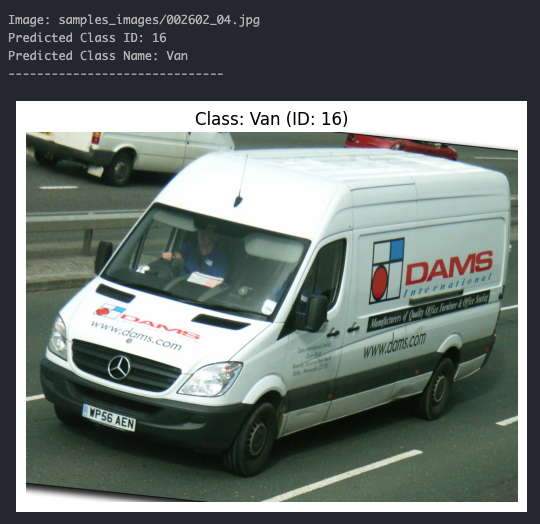

3. Edit the following code:
Complete the code snippet below so it loads an image and successfully predicts its class using your trained model.

In [ ]:
chosen_img_path = '/content/drive/My Drive/archive/EE331_inference_images'

################ Edit Here ################



################ Edit Here ################

output = model(input)
print(output)


AttributeError: ignored